# 데이터 준비

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

base_dir = "/content/drive/MyDrive/wafer-map-defect-xai"

folders = [
    "data/raw",
    "data/processed",
    "outputs/figures",
    "outputs/models",
    "outputs/reports"
]

for folder in folders:
    path = os.path.join(base_dir, folder)
    os.makedirs(path, exist_ok=True)

print("Google Drive folders created successfully!")

Google Drive folders created successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

data_path = "/content/drive/MyDrive/wafer-map-defect-xai/data/raw/LSWMD.pkl"

print(os.path.exists(data_path))
print(data_path)

True
/content/drive/MyDrive/wafer-map-defect-xai/data/raw/LSWMD.pkl


In [ ]:
import pandas as pd

df = pd.read_pickle("/content/drive/MyDrive/wafer-map-defect-xai/data/raw/LSWMD.pkl")

print(df.shape)
df.head()

(811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


# 0526

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np

BASE_PATH = "/content/drive/MyDrive/wafer-map-defect-xai"
PROCESSED_PATH = os.path.join(BASE_PATH, "data", "processed")
OUTPUT_PATH = os.path.join(BASE_PATH, "outputs")

MODEL_PATH = os.path.join(OUTPUT_PATH, "models")
FIGURE_PATH = os.path.join(OUTPUT_PATH, "figures")
REPORT_PATH = os.path.join(OUTPUT_PATH, "reports")

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(FIGURE_PATH, exist_ok=True)
os.makedirs(REPORT_PATH, exist_ok=True)

print("BASE_PATH exists:", os.path.exists(BASE_PATH))
print("PROCESSED_PATH exists:", os.path.exists(PROCESSED_PATH))
print(os.listdir(PROCESSED_PATH))

BASE_PATH exists: True
PROCESSED_PATH exists: True
['X_train.npy', 'X_val.npy', 'X_test.npy', 'y_val.npy', 'y_test.npy', 'y_train.npy', 'classes.npy']


# 전처리된 데이터 로드

In [3]:
X_train = np.load(os.path.join(PROCESSED_PATH, "X_train.npy"))
X_val = np.load(os.path.join(PROCESSED_PATH, "X_val.npy"))
X_test = np.load(os.path.join(PROCESSED_PATH, "X_test.npy"))

y_train = np.load(os.path.join(PROCESSED_PATH, "y_train.npy"))
y_val = np.load(os.path.join(PROCESSED_PATH, "y_val.npy"))
y_test = np.load(os.path.join(PROCESSED_PATH, "y_test.npy"))

classes = np.load(os.path.join(PROCESSED_PATH, "classes.npy"), allow_pickle=True)

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)

print("X_val:", X_val.shape, X_val.dtype)
print("y_val:", y_val.shape, y_val.dtype)

print("X_test:", X_test.shape, X_test.dtype)
print("y_test:", y_test.shape, y_test.dtype)

print("classes:", classes)

X_train: (121065, 64, 64, 1) uint8
y_train: (121065,) int64
X_val: (25942, 64, 64, 1) uint8
y_val: (25942,) int64
X_test: (25943, 64, 64, 1) uint8
y_test: (25943,) int64
classes: ['Center' 'Donut' 'Edge-Loc' 'Edge-Ring' 'Loc' 'Near-full' 'Random'
 'Scratch' 'none']


## 데이터 정상 여부 검증

In [4]:
assert len(X_train) == len(y_train), "X_train과 y_train 개수가 다릅니다."
assert len(X_val) == len(y_val), "X_val과 y_val 개수가 다릅니다."
assert len(X_test) == len(y_test), "X_test와 y_test 개수가 다릅니다."

assert X_train.shape[1:] == (64, 64, 1), "X_train 이미지 shape가 다릅니다."
assert X_val.shape[1:] == (64, 64, 1), "X_val 이미지 shape가 다릅니다."
assert X_test.shape[1:] == (64, 64, 1), "X_test 이미지 shape가 다릅니다."

print("데이터 검증 완료")

데이터 검증 완료


# 정규화
현재 X 값은 [0, 1, 2]이기 때문에 CNN에 넣기 전에 0~1 범위로 바꿔줘야 함

In [5]:
X_train = X_train.astype("float32") / 2.0
X_val = X_val.astype("float32") / 2.0
X_test = X_test.astype("float32") / 2.0

print("X_train dtype:", X_train.dtype)
print("X_train min/max:", X_train.min(), X_train.max())
print("X_val min/max:", X_val.min(), X_val.max())
print("X_test min/max:", X_test.min(), X_test.max())

X_train dtype: float32
X_train min/max: 0.0 1.0
X_val min/max: 0.0 1.0
X_test min/max: 0.0 1.0


# 클래스 분포 확인

In [6]:
import pandas as pd

train_counts = pd.Series(y_train).value_counts().sort_index()
val_counts = pd.Series(y_val).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

dist_df = pd.DataFrame({
    "class": classes,
    "train": train_counts.values,
    "val": val_counts.values,
    "test": test_counts.values
})

dist_df

,class,train,val,test
0,Center,3006,644,644
1,Donut,389,83,83
2,Edge-Loc,3632,778,779
3,Edge-Ring,6776,1452,1452
4,Loc,2515,539,539
5,Near-full,104,23,22
6,Random,606,130,130
7,Scratch,835,179,179
8,none,103202,22114,22115


# Class Weight 계산
이 데이터는 none 클래스가 너무 많아서 class weight를 적용하는 게 좋

In [7]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

class_weight_dict

{0: np.float64(4.474939010867154),
 1: np.float64(34.58011996572408),
 2: np.float64(3.703652716593245),
 3: np.float64(1.9851928374655647),
 4: np.float64(5.34857521537442),
 5: np.float64(129.34294871794873),
 6: np.float64(22.197469746974697),
 7: np.float64(16.109780439121757),
 8: np.float64(0.13034308120643656)}

# TensorFlow import 및 기본 설정

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

NUM_CLASSES = len(classes)
INPUT_SHAPE = X_train.shape[1:]

print("NUM_CLASSES:", NUM_CLASSES)
print("INPUT_SHAPE:", INPUT_SHAPE)

TensorFlow version: 2.20.0
NUM_CLASSES: 9
INPUT_SHAPE: (64, 64, 1)


# CNN 모델 정의

In [9]:
def build_cnn_model(input_shape=(64, 64, 1), num_classes=9):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation="softmax")
    ])

    return model

model = build_cnn_model(INPUT_SHAPE, NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,440,905 (5.50 MB)

 Trainable params: 1,439,945 (5.49 MB)

 Non-trainable params: 960 (3.75 KB)

## Callback 설정

In [10]:
checkpoint_path = os.path.join(MODEL_PATH, "best_cnn_model.keras")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

## 모델 학습

In [11]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2978 - loss: 2.8823
Epoch 1: val_loss improved from None to 1.56544, saving model to /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_model.keras
946/946 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.2891 - loss: 1.9949 - val_accuracy: 0.2372 - val_loss: 1.5654 - learning_rate: 0.0010
Epoch 2/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2532 - loss: 1.7287
Epoch 2: val_loss improved from 1.56544 to 1.32345, saving model to /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/wafer-map-defect-xai/outputs/models/best_cnn_model.keras
946/946 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.2179 - loss: 1.6739 - val_accuracy: 0.4939 - val_loss: 1.3235 - learning_rate: 0.0010
Epoch 3/30
946/94

### 테스트 평가

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

811/811 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9340 - loss: 0.2087
Test Loss: 0.20873484015464783
Test Accuracy: 0.9339706301689148


# 학습 곡선 시각화

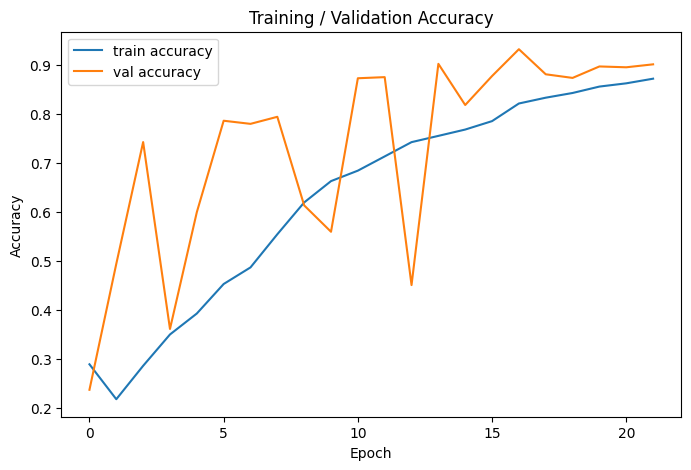

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training / Validation Accuracy")
plt.show()

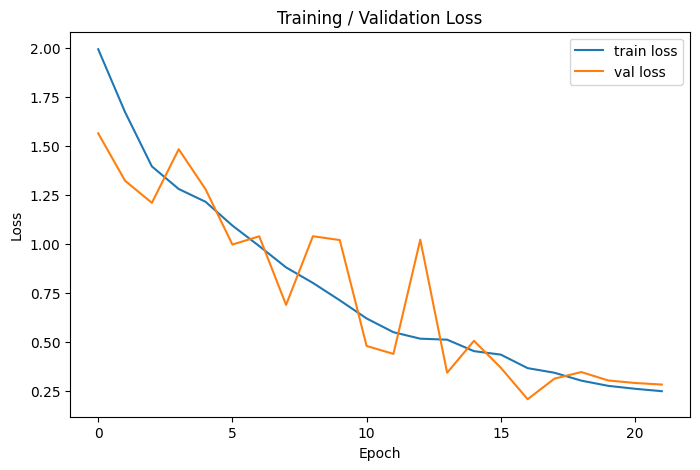

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training / Validation Loss")
plt.show()

# Confusion Matrix 확인

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

print(classification_report(y_test, y_pred, target_names=classes))

811/811 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step
              precision    recall  f1-score   support

      Center       0.83      0.95      0.88       644
       Donut       0.77      0.89      0.83        83
    Edge-Loc       0.59      0.78      0.67       779
   Edge-Ring       0.97      0.96      0.97      1452
         Loc       0.61      0.67      0.64       539
   Near-full       0.91      0.91      0.91        22
      Random       0.68      0.92      0.78       130
     Scratch       0.14      0.57      0.22       179
        none       0.99      0.95      0.97     22115

    accuracy                           0.93     25943
   macro avg       0.72      0.84      0.76     25943
weighted avg       0.96      0.93      0.94     25943



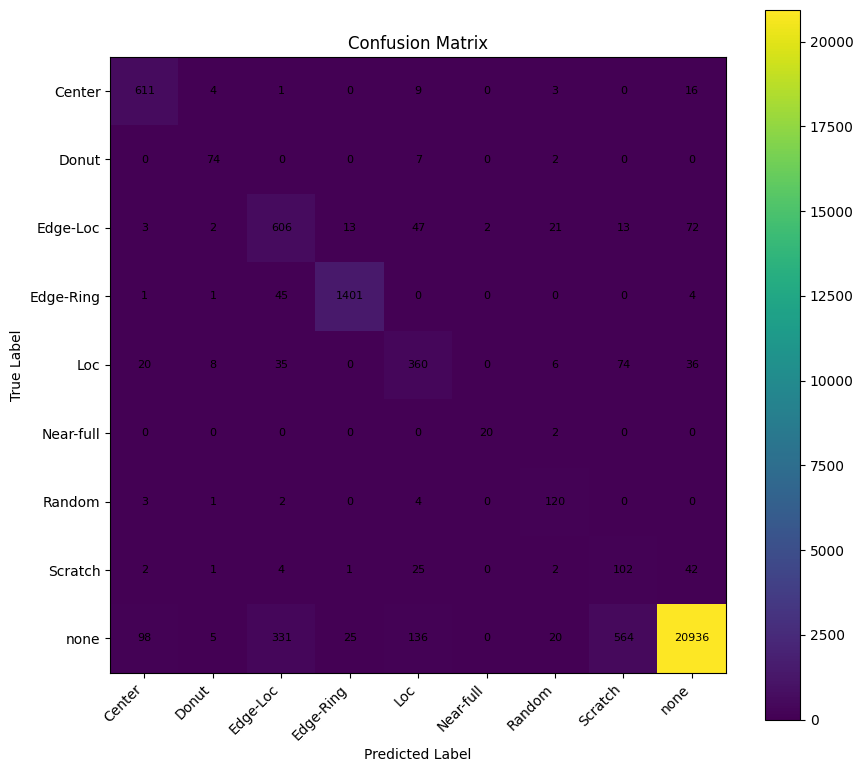

In [16]:
plt.figure(figsize=(9, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
plt.yticks(np.arange(len(classes)), classes)
plt.colorbar()

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()